In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=42)

In [4]:
df = pd.DataFrame(X, columns=['Feature_1','Feature_2'])

In [5]:
df.head()

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

**Elbow Method**

In [8]:
inertia = []
k_range = range(1,11)

In [10]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [11]:
inertia

[1000.0,
 297.8954141051722,
 11.57548472310498,
 9.748920654325133,
 8.25717527244628,
 6.9175773204167985,
 6.260760667208618,
 5.679769508143493,
 5.018204994760349,
 4.428456966876499]

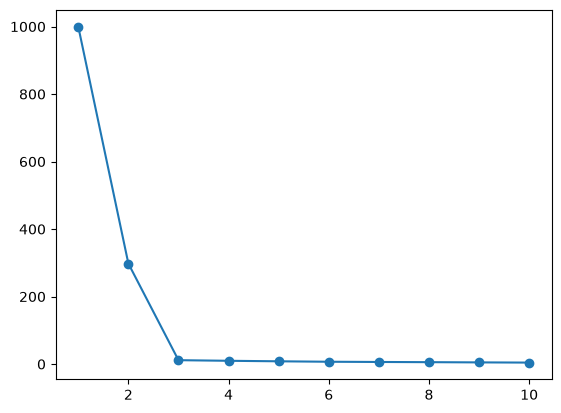

In [12]:
plt.plot(k_range, inertia, marker='o')

In [13]:
# the sudden drop stopped at 3 so we will create 3 cluster points
kmeans_final = KMeans(n_clusters=3, random_state=42)

In [14]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [15]:
df['cluster'] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

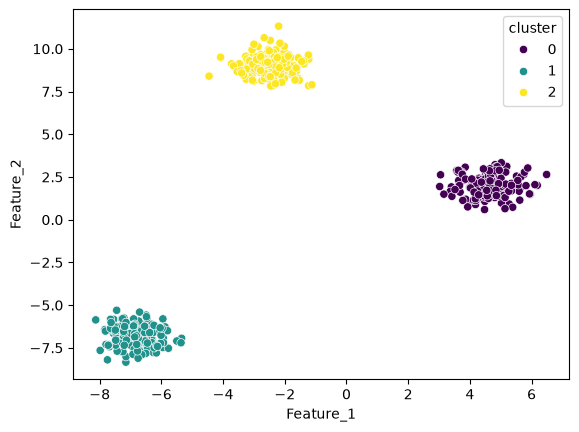

In [18]:
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['cluster'], palette='viridis')